# Helium.vX Python Demo

This notebook illustrates the neutral helium atom setup through the local `helium` Python extension. It focuses on helium levels, transition rates, TOPbase photoionization cross sections, and recombination/photoionization rates.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd()
if str(repo_root / "python" / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "python" / "src"))

from helium import (
    HEI_TRIPLET_TWO_PHOTON_2S_1S_RATE_PER_S,
    HEI_TWO_PHOTON_2S_1S_RATE_PER_S,
    helium,
)

plt.rcParams.update({"figure.figsize": (7.0, 4.4), "axes.grid": True})

## Build the helium atom

In [2]:
he = helium(shells=10)
he.summary()

{'n_shells': 10,
 'j_resolved_shells': 10,
 'quadrupole_shells': 10,
 'intercombination_shells': 10,
 'data_path': '/Users/user/Desktop/CosmoRec_Development/Atomic-Models/Helium-demo/Helium.vX/Helium.Data/',
 'level_count': 199,
 'photoionization_ready': True}

## Selected levels

In [3]:
selected_levels = [
    ("1$^1$S$_0$", he.level(1, 0, S=0, J=0)),
    ("2$^1$S$_0$", he.level(2, 0, S=0, J=0)),
    ("2$^1$P$_1$", he.level(2, 1, S=0, J=1)),
    ("2$^3$S$_1$", he.level(2, 0, S=1, J=1)),
    ("2$^3$P$_1$", he.level(2, 1, S=1, J=1)),
]

for label, level in selected_levels:
    print(
        f"{label:12s} Eion={level['ionization_energy_ev']:.8e} eV "
        f"DeltaE_1s2={level['energy_to_ground_ev']:.8e} eV "
        f"gw={level['statistical_weight']:.1f}"
    )

1$^1$S$_0$   Eion=2.45873872e+01 eV DeltaE_1s2=0.00000000e+00 eV gw=1.0
2$^1$S$_0$   Eion=3.97161247e+00 eV DeltaE_1s2=2.06157747e+01 eV gw=1.0
2$^1$P$_1$   Eion=3.36936460e+00 eV DeltaE_1s2=2.12180226e+01 eV gw=3.0
2$^3$S$_1$   Eion=4.76777275e+00 eV DeltaE_1s2=1.98196144e+01 eV gw=3.0
2$^3$P$_1$   Eion=3.62329093e+00 eV DeltaE_1s2=2.09640962e+01 eV gw=3.0


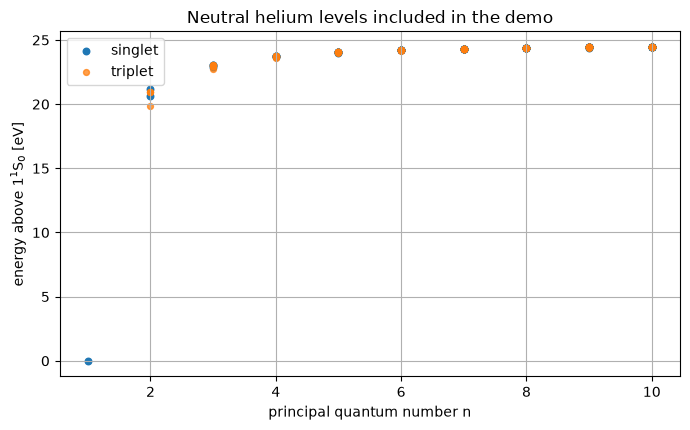

In [4]:
levels = he.levels()
singlets = [level for level in levels if level["S"] == 0]
triplets = [level for level in levels if level["S"] == 1]

fig, ax = plt.subplots()
ax.scatter(
    [level["n"] for level in singlets],
    [level["energy_to_ground_ev"] for level in singlets],
    s=22,
    label="singlet",
)
ax.scatter(
    [level["n"] for level in triplets],
    [level["energy_to_ground_ev"] for level in triplets],
    s=18,
    alpha=0.75,
    label="triplet",
)
ax.set_xlabel("principal quantum number n")
ax.set_ylabel("energy above 1$^1$S$_0$ [eV]")
ax.legend()
ax.set_title("Neutral helium levels included in the demo")
fig.tight_layout()

## Transition rates

In [5]:
transitions = [
    ("2$^1$P$_1$ -> 1$^1$S$_0$", he.transition(2, 1, 0, 1, 1, 0, 0, 0)),
    ("2$^3$P$_1$ -> 1$^1$S$_0$", he.transition(2, 1, 1, 1, 1, 0, 0, 0)),
    ("3$^1$D$_2$ -> 1$^1$S$_0$", he.transition(3, 2, 0, 2, 1, 0, 0, 0)),
]

for label, line in transitions:
    print(
        f"{label:28s} A21={line['a21_per_s']:.8e} 1/s "
        f"lambda={line['wavelength_angstrom']:.6e} Angstrom"
    )

2$^1$P$_1$ -> 1$^1$S$_0$     A21=1.79890000e+09 1/s lambda=5.843343e+02 Angstrom
2$^3$P$_1$ -> 1$^1$S$_0$     A21=1.77580000e+02 1/s lambda=5.914120e+02 Angstrom
3$^1$D$_2$ -> 1$^1$S$_0$     A21=1.29868163e+03 1/s lambda=5.373311e+02 Angstrom


## Two-photon rates

In [6]:
two_photon_rates = [
    ("2$^1$S$_0$ -> 1$^1$S$_0$", he.two_photon_rate(2, 0, 0, 0)),
    ("2$^3$S$_1$ -> 1$^1$S$_0$", he.two_photon_rate(2, 0, 1, 1)),
]

for label, rate in two_photon_rates:
    print(f"{label:28s} A2gamma={rate:.8e} 1/s")

print("singlet constant:", HEI_TWO_PHOTON_2S_1S_RATE_PER_S)
print("triplet constant:", HEI_TRIPLET_TWO_PHOTON_2S_1S_RATE_PER_S)

2$^1$S$_0$ -> 1$^1$S$_0$     A2gamma=5.13000000e+01 1/s
2$^3$S$_1$ -> 1$^1$S$_0$     A2gamma=4.02000000e-09 1/s
singlet constant: 51.3
triplet constant: 4.02e-09


## TOPbase photoionization cross sections

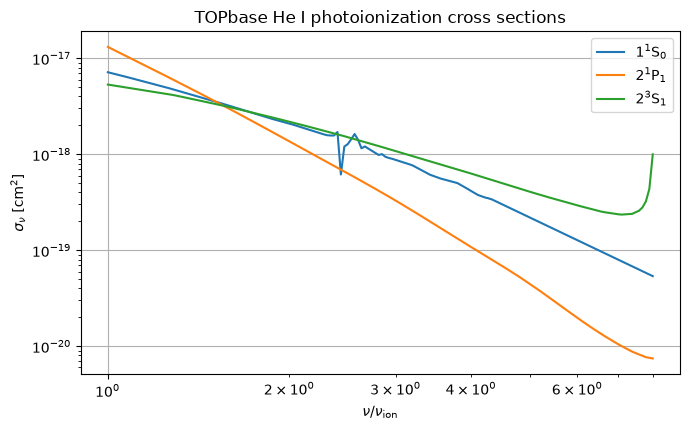

In [7]:
photo_levels = [
    ("1$^1$S$_0$", 1, 0, 0, 0),
    ("2$^1$P$_1$", 2, 1, 0, 1),
    ("2$^3$S$_1$", 2, 0, 1, 1),
]

fig, ax = plt.subplots()
for label, n, l, S, J in photo_levels:
    threshold = he.level(n, l, S=S, J=J)["ionization_frequency_hz"]
    nu = np.geomspace(1.001, 8.0, 160) * threshold
    data = he.topbase_photoionization(n, l, S, J, nu)
    ax.loglog(nu / threshold, data["sigma_cm2"], label=label)

ax.set_xlabel(r"$\nu / \nu_{\rm ion}$")
ax.set_ylabel(r"$\sigma_\nu$ [cm$^2$]")
ax.set_title("TOPbase He I photoionization cross sections")
ax.legend()
fig.tight_layout()

## Photoionization and recombination rates

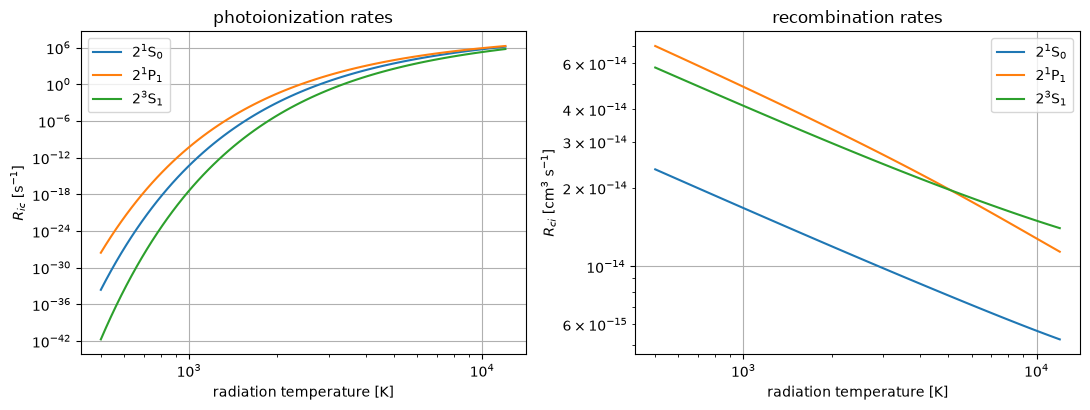

In [8]:
temperatures = np.geomspace(500.0, 12000.0, 80)
rate_levels = [
    ("2$^1$S$_0$", 2, 0, 0, 0),
    ("2$^1$P$_1$", 2, 1, 0, 1),
    ("2$^3$S$_1$", 2, 0, 1, 1),
]

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))
for label, n, l, S, J in rate_levels:
    ric = np.array([he.photoionization_rate(n, l, S, J, T) for T in temperatures])
    rci = np.array([he.recombination_rate(n, l, S, J, T) for T in temperatures])
    axes[0].loglog(temperatures, ric, label=label)
    axes[1].loglog(temperatures, rci, label=label)

axes[0].set_xlabel("radiation temperature [K]")
axes[0].set_ylabel(r"$R_{ic}$ [s$^{-1}$]")
axes[0].set_title("photoionization rates")
axes[1].set_xlabel("radiation temperature [K]")
axes[1].set_ylabel(r"$R_{ci}$ [cm$^3$ s$^{-1}$]")
axes[1].set_title("recombination rates")
for ax in axes:
    ax.legend()
fig.tight_layout()

## Fine-structure constant rescaling

In [9]:
line0 = he.transition(2, 1, 0, 1, 1, 0, 0, 0)
he.rescale(alpha_scale=1.01, electron_mass_scale=1.0)
line1 = he.transition(2, 1, 0, 1, 1, 0, 0, 0)
he.reset()

print(f"original frequency = {line0['frequency_hz']:.8e} Hz")
print(f"scaled frequency   = {line1['frequency_hz']:.8e} Hz")
print(f"ratio              = {line1['frequency_hz'] / line0['frequency_hz']:.8e}")

original frequency = 5.13049548e+15 Hz
scaled frequency   = 5.23361844e+15 Hz
ratio              = 1.02010000e+00
